In [271]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import os
os.getcwd()
os.chdir(r"C:\Users\athar\Downloads")
import scipy
from scipy import stats

import numpy as np
from numpy import random
import pandas as pd
import scipy
from scipy import stats

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend #heading, referred as label/scale
from pylab import plot, show, title, xlabel, ylabel 

import scipy
from scipy import stats
from scipy.stats import binom,poisson
from scipy.stats import expon
from scipy.stats import norm,t


In [243]:
binom.pmf(10,15,0.6)

0.18593784476467196

In [78]:
df=pd.read_excel("Values.xlsx")

In [79]:
df.head()

,Values
0,32
1,38
2,128
3,49
4,44


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Values  500 non-null    int64
dtypes: int64(1)
memory usage: 4.0 KB


In [81]:
Q3=np.percentile(df,75)

In [82]:
Q1=np.percentile(df,25)

In [83]:
Q2=np.percentile(df,50)

In [84]:
#IQR
IQR=56.25-43.0
IQR

13.25

In [85]:
#UB
UB=56.25+(1.5*13.25)
UB

76.125

In [86]:
#LB
LB=43-1.5*13.25
LB

23.125

In [87]:
(df.Values>UB).sum()

7

In [88]:
(df['Values']<LB).sum()

6

In [93]:
ind1=np.where((UB>=df.Values) & (df.Values>Q3)) #finding the whisker on higher side
ind2=np.where((LB<=df.Values) & (df.Values<Q1)) #finding the whisker on lower side

In [99]:
max(df.Values.iloc[ind1])


75

In [95]:
min(df.Values.iloc[ind2])

24

{'whiskers': [<matplotlib.lines.Line2D at 0x1816d947a10>,
 'caps': [<matplotlib.lines.Line2D at 0x1816d36bdd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1816d9443e0>],
 'medians': [<matplotlib.lines.Line2D at 0x1816b16f8f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1816d962090>],
 'means': []}

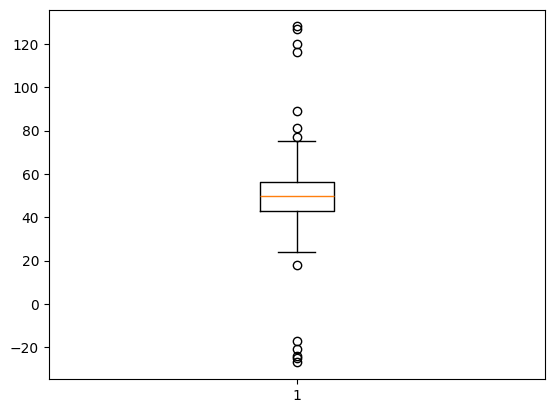

In [96]:
plt.boxplot(df.Values)

In [100]:
df=pd.read_excel("Travel.xlsx")

In [101]:
df.head()

,Gender,Location,TransportMode
0,Female,Suburbs,Cab
1,Male,City,Cab
2,Female,Towns,Bus
3,Female,Suburbs,LocalTrain
4,Male,Suburbs,Bus


In [114]:
a=df.Location.value_counts()
a

Location
Suburbs    2011
City       1787
Towns      1202
Name: count, dtype: int64

In [121]:
df1=df.TransportMode.value_counts()
#df1['counts']=df.TransportMode.value_counts()
#df1["Prop"]=df1['counts']/sum(df['counts'])


In [122]:
df1

TransportMode
Cab           1312
LocalTrain    1281
TwoWheeler    1230
Bus           1177
Name: count, dtype: int64

In [104]:
len(np.unique(df.Location))

3

In [129]:
x=df1.TransportMode.value_counts()
y=np.unique(df1.Transportmode)
plt.bar(x,y)

AttributeError: 'Series' object has no attribute 'TransportMode'

In [136]:
x=np.unique(df.Gender)
y=df.Location.value_counts()

Location
Suburbs    2011
City       1787
Towns      1202
Name: count, dtype: int64

<Axes: xlabel='TransportMode'>

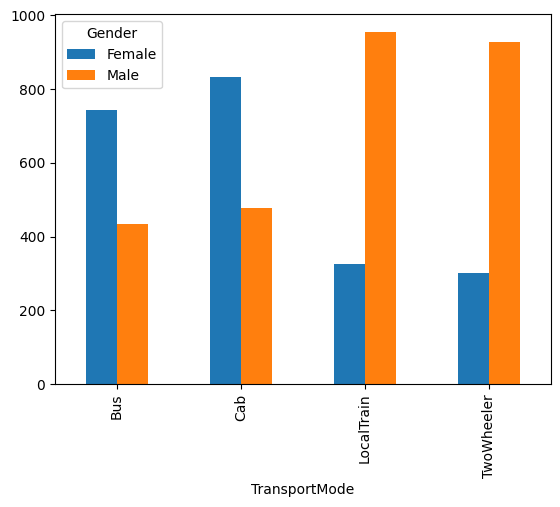

In [144]:
pd.crosstab(df.TransportMode,df.Gender).plot(kind='bar')

In [163]:
a=df.groupby(df.TransportMode)['Gender'].value_counts().reset_index()
a

,TransportMode,Gender,count
0,Bus,Female,744
1,Bus,Male,433
2,Cab,Female,834
3,Cab,Male,478
4,LocalTrain,Male,955
5,LocalTrain,Female,326
6,TwoWheeler,Male,928
7,TwoWheeler,Female,302


In [166]:
b=df.groupby(df.Location)['TransportMode'].value_counts().reset_index()
b

,Location,TransportMode,count
0,City,LocalTrain,601
1,City,Bus,587
2,City,TwoWheeler,305
3,City,Cab,294
4,Suburbs,Cab,769
5,Suburbs,TwoWheeler,434
6,Suburbs,LocalTrain,424
7,Suburbs,Bus,384
8,Towns,TwoWheeler,491
9,Towns,LocalTrain,256


<Axes: xlabel='Location'>

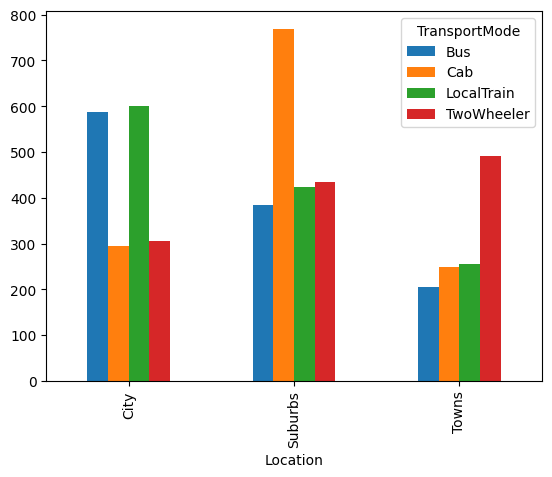

In [168]:
pd.crosstab(df.Location,df.TransportMode).plot(kind='bar')

In [193]:
new=pd.read_excel("Responses.xlsx")

In [194]:
new.isna().sum()

Gender        441
Education     245
Occupation    368
Response1     175
Response2     200
dtype: int64

In [195]:
new.head()

,Gender,Education,Occupation,Response1,Response2
0,Male,HighSchool,Banking,115.4,23.0
1,NaN,NaN,Software,38.0,26.0
2,NaN,College,Manufacturing,56.7,36.0
3,Male,PostGrad,Manufacturing,52.6,38.0
4,Male,PostGrad,Banking,62.7,55.0


In [196]:
new.Gender.mode()

0    Male
Name: Gender, dtype: object

In [197]:
new['Gender']=new.Gender.fillna("Male")

In [198]:
new.head()

,Gender,Education,Occupation,Response1,Response2
0,Male,HighSchool,Banking,115.4,23.0
1,Male,NaN,Software,38.0,26.0
2,Male,College,Manufacturing,56.7,36.0
3,Male,PostGrad,Manufacturing,52.6,38.0
4,Male,PostGrad,Banking,62.7,55.0


In [199]:
new.isna().sum()

Gender          0
Education     245
Occupation    368
Response1     175
Response2     200
dtype: int64

In [205]:
new['Education']=new.Education.fillna(new.Education.mode()) ###Check working

In [207]:
new.Education.mode()

0    PostGrad
Name: Education, dtype: object

In [208]:
new['Education']=new.Education.fillna('PostGrad')

In [209]:
new.isna().sum()

Gender          0
Education       0
Occupation    368
Response1     175
Response2     200
dtype: int64

In [211]:
new.Occupation.mode()

0    SelfEmployed
Name: Occupation, dtype: object

In [212]:
new['Occupation']=new.Occupation.fillna('SelfEmployed')

In [214]:
new.isna().sum()

Gender          0
Education       0
Occupation      0
Response1     175
Response2     200
dtype: int64

In [216]:
new.Response1=new.Response1.fillna(new.Response1.median())

In [217]:
new.isna().sum()

Gender          0
Education       0
Occupation      0
Response1       0
Response2     200
dtype: int64

In [218]:
new.Response2=new.Response2.fillna(new.Response2.median())

In [219]:
new.isna().sum()

Gender        0
Education     0
Occupation    0
Response1     0
Response2     0
dtype: int64

In [220]:
new.groupby(new.Gender)['Response1'].sum()


Gender
Female    133336.0
Male      165907.7
Name: Response1, dtype: float64

In [225]:
dfm=new.iloc[np.where(new.Gender=='Male')]

In [226]:
dff=new.iloc[np.where(new.Gender=='Female')]

<Axes: xlabel='Gender', ylabel='Response1'>

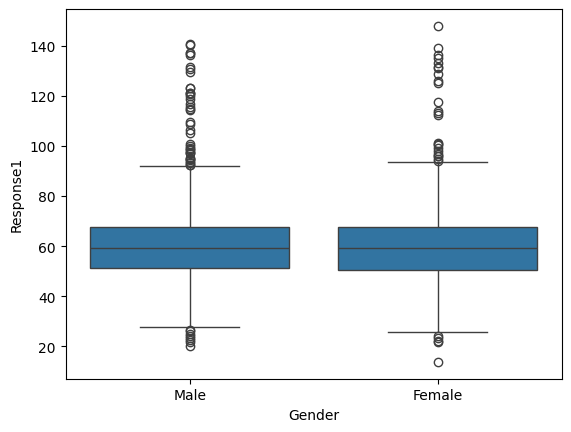

In [228]:
sns.boxplot(x=new.Gender,y=new.Response1)

<Axes: xlabel='Education', ylabel='Response1'>

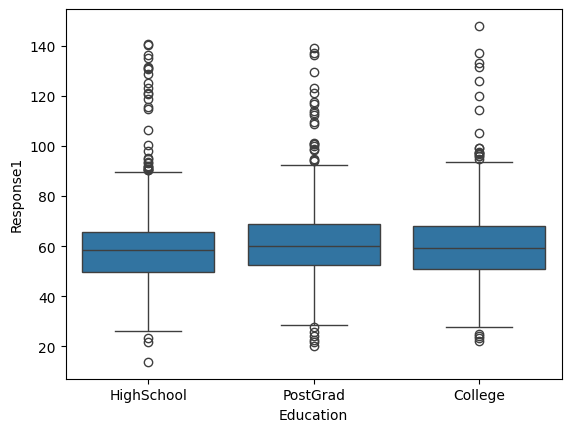

In [231]:
sns.boxplot(x=new.Education,y=new.Response1)

In [ ]:
#effect of categorical data on continous data we use box plot

In [235]:
 df=pd.read_csv("Churn_Modelling.csv")

In [237]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
#discrete==>binolial and poisson 
"""
continuous==>exponential,normal and student's distribution

,
binolial and poisson -always used for discrete data
binomial is used when there are only two possibilites

The prob of single occurance is known,and then we use B.D. to calculate the prob the particular range of events


"""


In [251]:
binom.cdf(8,15,0.6)-binom.cdf(2,15,0.6)

0.38990793985228833

In [256]:
ct=0
for i in range(3,9):
    ct+=binom.pmf(i,15,0.6)
ct

0.38990793985228833

In [ ]:
#mean of binomial distribution is n*p

In [ ]:
#on an avg 50 accidents are reported in a city
"""
Q1-What is the prob of exactly 45 accidents taking place today
Q2-What is the prob of upto 45 accidents takin place today.
Q3- What is the prob of minimum 45 accidents taking place today


"""

In [257]:
poisson.pmf(45,50) #A!

0.045826241434197924

In [258]:
poisson.cdf(45,50) #A2

0.2668664740596442

In [265]:
poisson.sf(44,50) 
1-poisson.cdf(44,50) #A3

0.7789597673745553

In [270]:
#what is the prob that event occures in next 100 hours
expon.cdf(100,scale=43.8)
1-expon.cdf(100,scale=43.8)

0.10196710447804302

In [ ]:
expon.ppf()

In [ ]:
#avg time to kolhapur from mumbai is 5 hrs with std its 1.3hrs
"""
Q1-what is prob that I will take less than 4.5 hrs
Q2-What is the prob that I will take more than 4.5 hrs
Q3-What is prob that i wll take time betn 4.2 and 5.3 hrs

"""

In [273]:
#Ans1
norm.cdf(4.5,5,1.3)
#35 percent time will reach in less than 4.5 hrs

0.3502611970519244

In [274]:
#Ans2
1-norm.cdf(4.5,5,1.3)
#65 per prob that will requrire more than 4.5hrs

0.6497388029480756

In [276]:
norm.cdf(5.3,5,1.3)-norm.cdf(4.2,5,1.3)
#32 per chance that we will reach in this time

0.32210258230894806

In [279]:
#what is time below which 65 per of trips will be completed


In [280]:
norm.cdf(-0.3846153846153846)

0.3502611970519244